In [62]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import seaborn as sns

In [63]:
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42

figure_colors = {
    "OMC": "black",  
    "RTMW: Performance": "#3ec5ef",  
    'HSMR': "#ff886b",  
    "SOC": "#a274d4",  
}

title_fontsize = 14
axis_fontsize = 10
legend_fontsize = 10
tick_fontsize = 10
alpha = 1

In [64]:
project_root = Path.cwd()
if (project_root / 'data' / 'raw').exists():
    pass
elif (project_root.parent / 'data' / 'raw').exists():
    project_root = project_root.parent
else:
    raise FileNotFoundError("Could not find data/raw from current working directory.")

raw_dir = project_root / 'data' / 'raw'
out_dir = project_root / 'figures'
out_dir.mkdir(parents=True, exist_ok=True)

hsmr = pd.read_csv(raw_dir / 'hsmr_paired_measurements.csv')
rtmw = pd.read_csv(raw_dir / 'rtmw_paired_measurements.csv')

In [65]:
rtmw_flexion = rtmw[(rtmw['motion'] == 'flexion') & (rtmw['camera'] == 'straight')][['hpe', 'vicon']]
rtmw_extension = rtmw[(rtmw['motion'] == 'extension') & (rtmw['camera'] == 'straight')][['hpe', 'vicon']]

hsmr_flexion = hsmr[(hsmr['motion'] == 'flexion') & (hsmr['camera'] == 'straight')][['hpe', 'vicon']]
hsmr_extension = hsmr[(hsmr['motion'] == 'extension') & (hsmr['camera'] == 'straight')][['hpe', 'vicon']]

soc_flexion = hsmr[(hsmr['motion'] == 'flexion') & (hsmr['camera'] == 'straight')][['soc', 'vicon']]
soc_extension = hsmr[(hsmr['motion'] == 'extension') & (hsmr['camera'] == 'straight')][['soc', 'vicon']]

In [66]:
rtmw_flexion_error = rtmw_flexion['hpe'] - rtmw_flexion['vicon']
rtmw_extension_error = rtmw_extension['hpe'] - rtmw_extension['vicon']

hsmr_flexion_error = hsmr_flexion['hpe'] - hsmr_flexion['vicon']
hsmr_extension_error = hsmr_extension['hpe'] - hsmr_extension['vicon']

soc_flexion_error = soc_flexion['soc'] - soc_flexion['vicon']
soc_extension_error = soc_extension['soc'] - soc_extension['vicon']

In [67]:
df_flexion_diffs_plot = pd.DataFrame([rtmw_flexion_error.values, hsmr_flexion_error.values, soc_flexion_error.values])
df_flexion_diffs_plot = df_flexion_diffs_plot.transpose()
df_flexion_diffs_plot.columns = ['RTMW: Performance', 'HSMR', 'SOC']

df_extension_diffs_plot = pd.DataFrame([rtmw_extension_error.values, hsmr_extension_error.values, soc_extension_error.values])
df_extension_diffs_plot = df_extension_diffs_plot.transpose()
df_extension_diffs_plot.columns = ['RTMW: Performance', 'HSMR', 'SOC']

In [68]:
# mean error
mean_rtmw_flexion = df_flexion_diffs_plot['RTMW: Performance'].mean()
print(f'Mean Error RTMW Flexion: {mean_rtmw_flexion:.2f}')
mean_hsmr_flexion = df_flexion_diffs_plot['HSMR'].mean()
print(f'Mean Error HSMR Flexion: {mean_hsmr_flexion:.2f}')
mean_soc_flexion = df_flexion_diffs_plot['SOC'].mean()
print(f'Mean Error SOC Flexion: {mean_soc_flexion:.2f}')

# median error
median_rtmw_flexion = df_flexion_diffs_plot['RTMW: Performance'].median()
print(f'Median Error RTMW Flexion: {median_rtmw_flexion:.2f}')
median_hsmr_flexion = df_flexion_diffs_plot['HSMR'].median()
print(f'Median Error HSMR Flexion: {median_hsmr_flexion:.2f}')
median_soc_flexion = df_flexion_diffs_plot['SOC'].median()
print(f'Median Error SOC Flexion: {median_soc_flexion:.2f}')

# mean absolute error
mae_rtmw_flexion = df_flexion_diffs_plot['RTMW: Performance'].abs().mean()
print(f'Mean Absolute Error RTMW Flexion: {mae_rtmw_flexion:.2f}')
mae_hsmr_flexion = df_flexion_diffs_plot['HSMR'].abs().mean()
print(f'Mean Absolute Error HSMR Flexion: {mae_hsmr_flexion:.2f}')
mae_soc_flexion = df_flexion_diffs_plot['SOC'].abs().mean()
print(f'Mean Absolute Error SOC Flexion: {mae_soc_flexion:.2f}')

# root mean square error
rmse_rtmw_flexion = np.sqrt(((df_flexion_diffs_plot['RTMW: Performance']) ** 2).mean())
print(f'Root Mean Square Error RTMW Flexion: {rmse_rtmw_flexion:.2f}')
rmse_hsmr_flexion = np.sqrt(((df_flexion_diffs_plot['HSMR']) ** 2).mean())
print(f'Root Mean Square Error HSMR Flexion: {rmse_hsmr_flexion:.2f}')
rmse_soc_flexion = np.sqrt(((df_flexion_diffs_plot['SOC']) ** 2).mean())
print(f'Root Mean Square Error SOC Flexion: {rmse_soc_flexion:.2f}')

Mean Error RTMW Flexion: 10.75
Mean Error HSMR Flexion: -1.70
Mean Error SOC Flexion: -2.15
Median Error RTMW Flexion: 10.35
Median Error HSMR Flexion: -1.17
Median Error SOC Flexion: -1.35
Mean Absolute Error RTMW Flexion: 10.94
Mean Absolute Error HSMR Flexion: 4.95
Mean Absolute Error SOC Flexion: 5.42
Root Mean Square Error RTMW Flexion: 12.18
Root Mean Square Error HSMR Flexion: 6.01
Root Mean Square Error SOC Flexion: 7.31


In [69]:
# mean error
mean_rtmw_extension = df_extension_diffs_plot['RTMW: Performance'].mean()
print(f'Mean Error RTMW Extension: {mean_rtmw_extension:.2f}')
mean_hsmr_extension = df_extension_diffs_plot['HSMR'].mean()
print(f'Mean Error HSMR Extension: {mean_hsmr_extension:.2f}')
mean_soc_extension = df_extension_diffs_plot['SOC'].mean()
print(f'Mean Error SOC Extension: {mean_soc_extension:.2f}')

# median error
median_rtmw_extension = df_extension_diffs_plot['RTMW: Performance'].median()
print(f'Median Error RTMW Extension: {median_rtmw_extension:.2f}')
median_hsmr_extension = df_extension_diffs_plot['HSMR'].median()
print(f'Median Error HSMR Extension: {median_hsmr_extension:.2f}')
median_soc_extension = df_extension_diffs_plot['SOC'].median()
print(f'Median Error SOC Extension: {median_soc_extension:.2f}')

# mean absolute error
mae_rtmw_extension = df_extension_diffs_plot['RTMW: Performance'].abs().mean()
print(f'Mean Absolute Error RTMW Extension: {mae_rtmw_extension:.2f}')
mae_hsmr_extension = df_extension_diffs_plot['HSMR'].abs().mean()
print(f'Mean Absolute Error HSMR Extension: {mae_hsmr_extension:.2f}')
mae_soc_extension = df_extension_diffs_plot['SOC'].abs().mean()
print(f'Mean Absolute Error SOC Extension: {mae_soc_extension:.2f}')

# root mean square error
rmse_rtmw_extension = np.sqrt(((df_extension_diffs_plot['RTMW: Performance']) ** 2).mean())
print(f'Root Mean Square Error RTMW Extension: {rmse_rtmw_extension:.2f}')
rmse_hsmr_extension = np.sqrt(((df_extension_diffs_plot['HSMR']) ** 2).mean())
print(f'Root Mean Square Error HSMR Extension: {rmse_hsmr_extension:.2f}')
rmse_soc_extension = np.sqrt(((df_extension_diffs_plot['SOC']) ** 2).mean())
print(f'Root Mean Square Error SOC Extension: {rmse_soc_extension:.2f}')

Mean Error RTMW Extension: 3.78
Mean Error HSMR Extension: 1.86
Mean Error SOC Extension: 2.72
Median Error RTMW Extension: 2.75
Median Error HSMR Extension: 1.19
Median Error SOC Extension: 2.99
Mean Absolute Error RTMW Extension: 5.47
Mean Absolute Error HSMR Extension: 6.31
Mean Absolute Error SOC Extension: 5.20
Root Mean Square Error RTMW Extension: 7.38
Root Mean Square Error HSMR Extension: 8.28
Root Mean Square Error SOC Extension: 6.47


In [70]:
df_flexion_plot = pd.DataFrame([rtmw_flexion['vicon'].values, rtmw_flexion['hpe'].values, hsmr_flexion['hpe'].values, soc_flexion['soc'].values])
df_flexion_plot = df_flexion_plot.transpose()
df_flexion_plot.columns = ['OMC', 'RTMW: Performance', 'HSMR', 'SOC']

df_extension_plot = pd.DataFrame([rtmw_extension['vicon'].values, rtmw_extension['hpe'].values, hsmr_extension['hpe'].values, soc_extension['soc'].values])
df_extension_plot = df_extension_plot.transpose()
df_extension_plot.columns = ['OMC', 'RTMW: Performance', 'HSMR', 'SOC'] 

/home/darode/miniconda3/envs/notebook/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 31.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/darode/miniconda3/envs/notebook/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 34.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/darode/miniconda3/envs/notebook/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 35.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/darode/miniconda3/envs/notebook/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 28.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/da

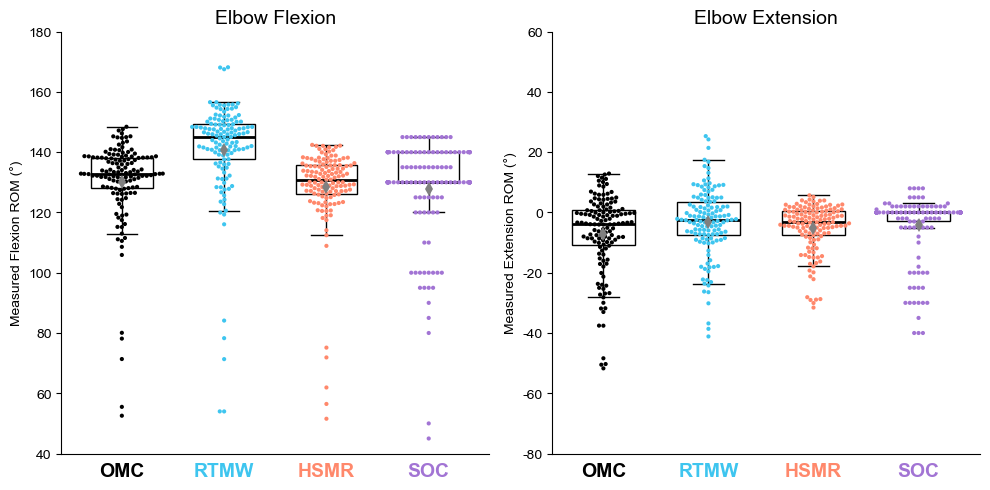

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

#################################################
sns.boxplot(x='variable',
            y='value',
            data=pd.melt(df_flexion_plot),
            ax=ax[0],
            showfliers=False,
            palette=figure_colors,
            width=0.6,
            zorder=1,
            boxprops=dict(
                facecolor="None",  # Box color
                edgecolor="black"),  # Box color
            whiskerprops=dict(color="black"),  # Whisker color
            capprops=dict(color="black"),  # Caps color
            medianprops=dict(
                color="black",  # Median line color
                linewidth=2
                ), 
            hue='variable',  # Add hue based on the x-variable
            legend=False)  # Disable the legend for the boxplot

sns.swarmplot(x='variable',
              y='value',
              data=pd.melt(df_flexion_plot),
              ax=ax[0],
              hue='variable',
            #   palette='dark:black',  # Use the recommended palette for black
              palette=figure_colors,  # Use the same colors as the boxplot
              linewidth=0,
              edgecolor='none',
              alpha=alpha,
              zorder=2,
              legend=False,
              size=3) # Disable the legend for the stripplot

# Add mean markers for each box (use triangle for mean with the same color as the box)
for i, col in enumerate(df_flexion_plot.columns):
    mean = df_flexion_plot[col].mean()
    ax[0].plot(i, 
               mean, 
               marker='d', 
               color='grey',
               markersize=7, 
               markeredgewidth=0, 
               label=None, 
               zorder=3, 
               markeredgecolor='none',
               alpha=alpha,
               )

#################################################
sns.boxplot(x='variable',
            y='value',
            data=pd.melt(df_extension_plot),
            ax=ax[1],
            showfliers=False,
            palette=figure_colors,
            width=0.6,
            zorder=1,
            boxprops=dict(
                facecolor="None",  # Box fill color
                edgecolor="black"),  # Box color
            whiskerprops=dict(color="black"),  # Whisker color
            capprops=dict(color="black"),  # Caps color
            medianprops=dict(
                color="black",  # Median line color
                linewidth=2
                ), 
            hue='variable',  # Add hue based on the x-variable
            legend=False)  # Disable the legend for the boxplot

sns.swarmplot(x='variable',
              y='value',
              data=pd.melt(df_extension_plot),
              ax=ax[1],
              hue='variable',
            #   palette='dark:black',  # Use the recommended palette for black
              palette=figure_colors,  # Use the same colors as the boxplot
              linewidth=0,
              edgecolor='none',
              alpha=alpha,
              zorder=2,
              legend=False,
              size=3) # Disable the legend for the stripplot

for i, col in enumerate(df_extension_plot.columns):
    mean = df_extension_plot[col].mean()
    ax[1].plot(i, 
               mean, 
               marker='d', 
               color='grey', 
               markersize=7, 
               markeredgewidth=0, 
               label=None, 
               zorder=3,
               markeredgecolor='none',
               alpha=alpha,
               )
################################################
ax[0].set_title('Elbow Flexion', fontsize=title_fontsize)
ax[1].set_title('Elbow Extension', fontsize=title_fontsize)

for axis in ax:

    
    axis.set_xlabel('', fontsize=axis_fontsize)

    axis.set_xticks([])

    if axis == ax[0]:
        axis.set_ylabel('Measured Flexion ROM (°)', fontsize=axis_fontsize, ha='center')
        axis.set_ylim(40, 180)
        axis.set_yticks([40, 60, 80, 100, 120, 140, 160, 180]) # Set the y-ticks explicitly
        axis.set_yticklabels([40, 60, 80, 100, 120, 140, 160, 180], fontsize=tick_fontsize)
    else:
        axis.set_ylabel('Measured Extension ROM (°)', fontsize=axis_fontsize, ha='center')
        axis.set_ylim(-80, 60)
        axis.set_yticks([-80, -60, -40, -20, 0, 20, 40, 60])
        axis.set_yticklabels([-80, -60, -40, -20, 0, 20, 40, 60], fontsize=tick_fontsize)

    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)
    axis.spines['left'].set_visible(True)
    axis.spines['bottom'].set_visible(True)

    # Iterate over the boxplots and add text labels
    labels = ['OMC', 'RTMW', 'HSMR', 'SOC']
    y_min, y_max = axis.get_ylim()
    label_y = y_min - (y_max - y_min) * 0.02  # Place labels slightly below the minimum value
        
    for i, label in enumerate(labels):
        color = [*figure_colors.values()][i]
        axis.text(
            i,  # x-coordinate (adjusted for each group of 3 metrics)
            label_y,  # y-coordinate (slightly above the max value of the boxplot)
            label,
            ha='center',  # horizontal alignment
            va='top',  # vertical alignment
            fontsize=title_fontsize,
            color=color,
            weight = 'bold',
            alpha = 1
        )
    

################################################
fig.tight_layout()
fig.savefig(out_dir / '01_boxplot_abs.pdf', bbox_inches='tight')

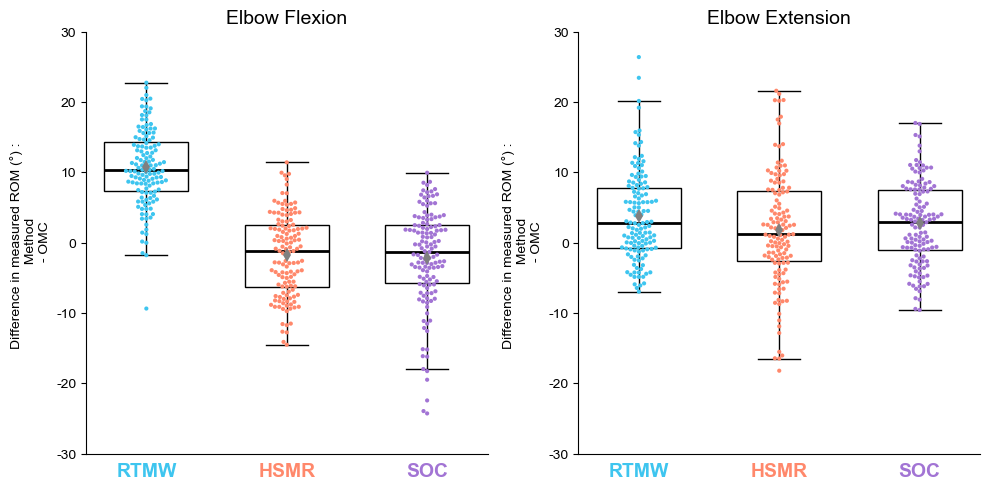

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

#################################################
sns.boxplot(x='variable',
            y='value',
            data=pd.melt(df_flexion_diffs_plot),
            ax=ax[0],
            showfliers=False,
            palette=figure_colors,
            width=0.6,
            zorder=1,
            boxprops=dict(
                facecolor="None",  # Box fill color
                edgecolor="black"),  # Box color
            whiskerprops=dict(color="black"),  # Whisker color
            capprops=dict(color="black"),  # Caps color
            medianprops=dict(
                color="black",  # Median line color
                linewidth=2
                ), 
            hue='variable',  # Add hue based on the x-variable
            legend=False)  # Disable the legend for the boxplot

sns.swarmplot(x='variable',
              y='value',
              data=pd.melt(df_flexion_diffs_plot),
              ax=ax[0],
              hue='variable',
            #   palette='dark:black',  # Use the recommended palette for black
              palette=figure_colors,  # Use the same colors as the boxplot
              zorder=2,
              linewidth=0,
              edgecolor='none',
              alpha=alpha,
              legend=False,
              size=3) # Disable the legend for the stripplot

# Add mean markers for each box (use triangle for mean with the same color as the box)
for i, col in enumerate(df_flexion_diffs_plot.columns):
    mean = df_flexion_diffs_plot[col].mean()
    ax[0].plot(i, 
               mean, 
               marker='d', 
               color='grey', 
               markersize=7, 
               markeredgewidth=0, 
               label=None, 
               zorder=3,
               markeredgecolor='none',
               alpha=alpha,
               )

#################################################
sns.boxplot(x='variable',
            y='value',
            data=pd.melt(df_extension_diffs_plot),
            ax=ax[1],
            showfliers=False,
            palette=figure_colors,
            width=0.6,
            zorder=1,
            boxprops=dict(
                facecolor="None",  # Box fill color
                edgecolor="black"),  # Box color
            whiskerprops=dict(color="black"),  # Whisker color
            capprops=dict(color="black"),  # Caps color
            medianprops=dict(
                color="black",  # Median line color
                linewidth=2
                ), 
            hue='variable',  # Add hue based on the x-variable
            legend=False)  # Disable the legend for the boxplot

sns.swarmplot(x='variable',
              y='value',
              data=pd.melt(df_extension_diffs_plot),
              ax=ax[1],
              hue='variable',
            #   palette='dark:black',  # Use the recommended palette for black
              palette=figure_colors,  # Use the same colors as the boxplot
              zorder=2,
              linewidth=0,
              edgecolor='none',
              alpha=alpha,
              legend=False,
              size=3) # Disable the legend for the stripplot

for i, col in enumerate(df_extension_diffs_plot.columns):
    mean = df_extension_diffs_plot[col].mean()
    ax[1].plot(i, 
               mean, 
               marker='d', 
               color='grey', 
               markersize=7, 
               markeredgewidth=0, 
               label=None, 
               zorder=3,
               markeredgecolor='none',
               alpha=alpha,
               )
################################################
ax[0].set_title('Elbow Flexion', fontsize=title_fontsize)
ax[1].set_title('Elbow Extension', fontsize=title_fontsize)

for axis in ax:

    axis.set_ylabel('Difference in measured ROM (°) : \n Method\n - OMC', fontsize=axis_fontsize, ha='center')
    axis.set_xlabel('', fontsize=axis_fontsize)

    axis.set_xticks([])

    axis.set_ylim(-30, 30)
    axis.set_yticks([-30, -20, -10, 0, 10, 20, 30]) # Set the y-ticks explicitly
    axis.set_yticklabels([-30, -20, -10, 0, 10, 20, 30], fontsize=tick_fontsize)

    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)
    axis.spines['left'].set_visible(True)
    axis.spines['bottom'].set_visible(True)

    # Iterate over the boxplots and add text labels
    y_min, y_max = axis.get_ylim()
    label_y = y_min - (y_max - y_min) * 0.02  # Place labels slightly below the minimum value

    labels = ['RTMW', 'HSMR', 'SOC']
    for i, label in enumerate(labels):
        color = [*figure_colors.values()][i+1]
        axis.text(
            i,  # x-coordinate (adjusted for each group of 3 metrics)
            label_y,  # y-coordinate (slightly above the max value of the boxplot)
            label,
            ha='center',  # horizontal alignment
            va='top',  # vertical alignment
            fontsize=title_fontsize,
            color=color,
            weight = 'bold',
            alpha = 1
        )
    

################################################
fig.tight_layout()
fig.savefig(out_dir / '01_boxplot_diffs.pdf', bbox_inches='tight')